<a href="https://colab.research.google.com/github/kirthiksaran7777-afk/python-project-6/blob/main/python_project_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.4 MB/s eta 0:00:00


In [15]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns







In [16]:
!pip install faker

Dataset Created Successfully!
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Mean:
 Age                   43.995920
Tenure                 4.991050
Balance            99912.714949
CreditScore          599.562160
EstimatedSalary    79922.498467
NumOfProducts          2.503650
IsActiveMember         0.500310
Churn                  0.041940
dtype: float64

Median:
 Age                   44.000
Tenure                 5.000
Balance            99783.035
CreditScore          600.000
EstimatedSalary    80070.520
NumOfProducts          3.000
IsActiveMember         1.000
Churn                  0.000
dtype: float64

Std Dev:
 Age                   15.288492
Tenure                 3.159764
Balance            57623.189671
CreditScore          173.459744
EstimatedSalary    40546.867680
NumOfProducts          1.119517
IsActiveM

/tmp/ipykernel_478/2577438973.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


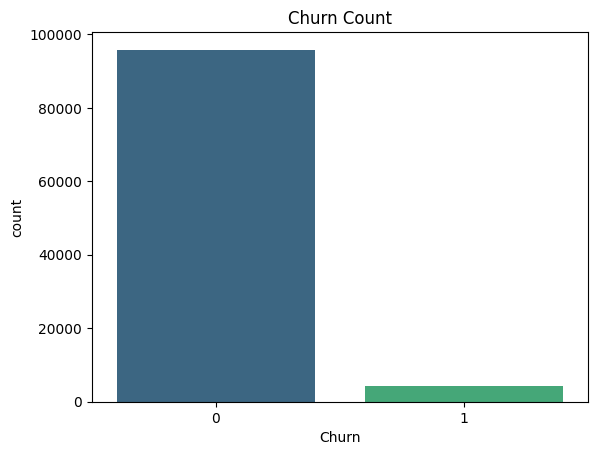

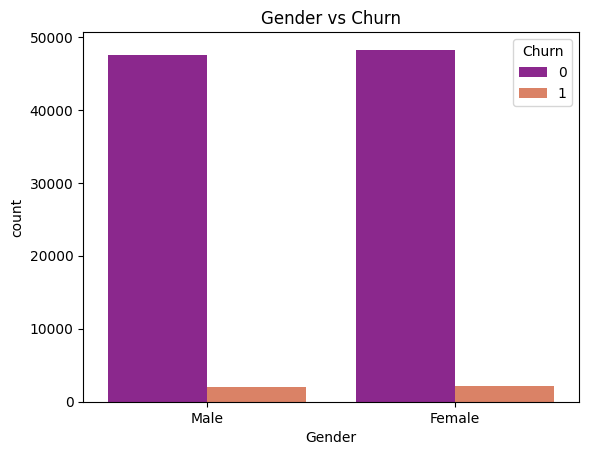

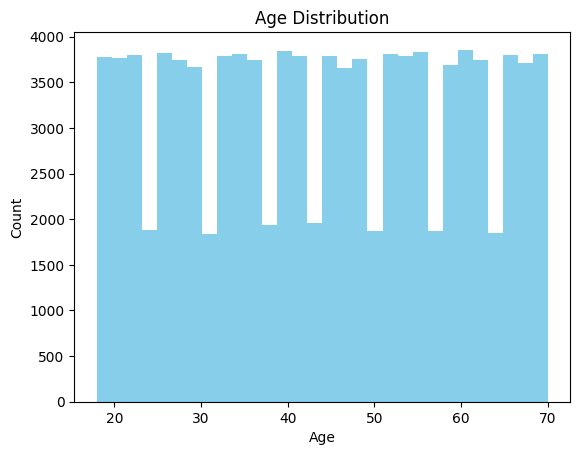

/tmp/ipykernel_478/2577438973.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')


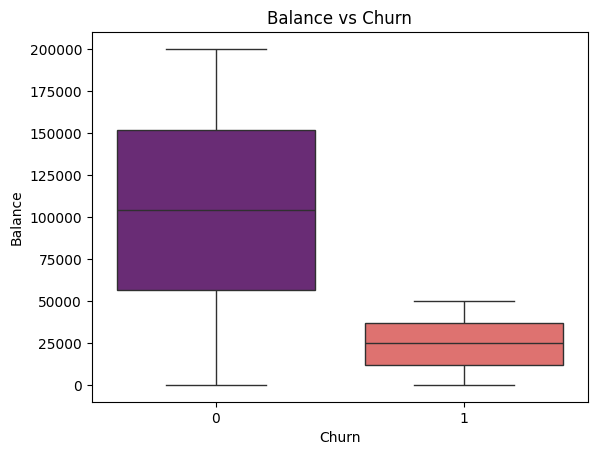

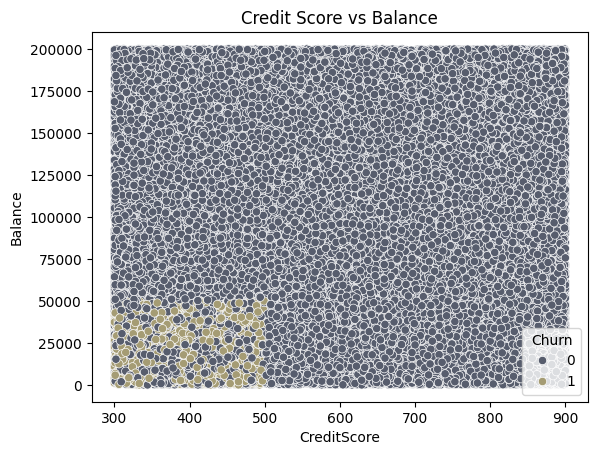

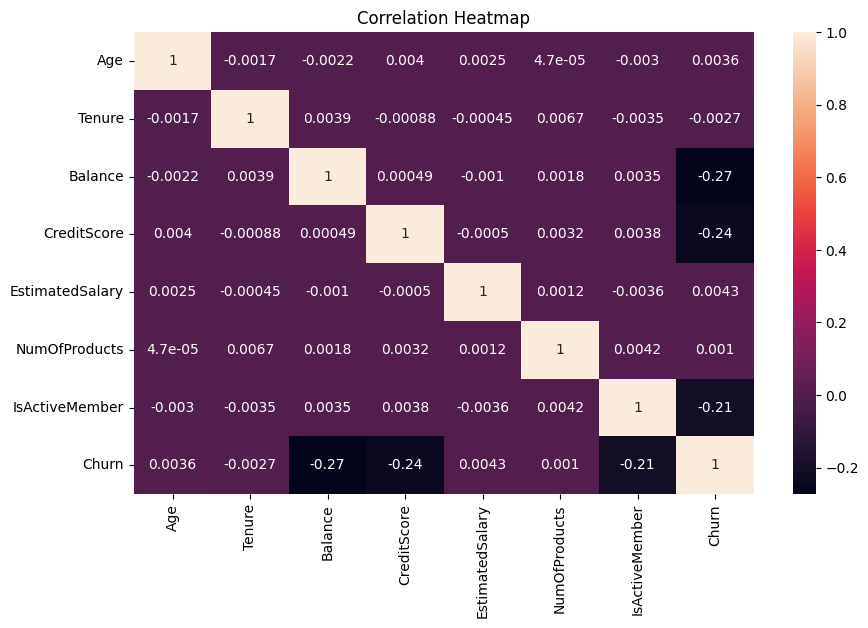

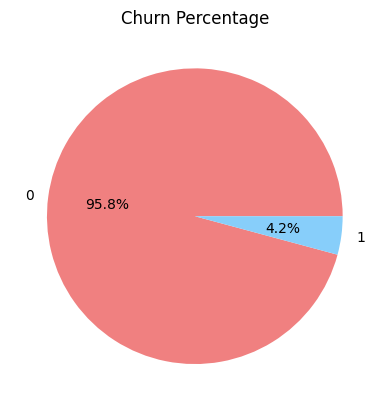

In [17]:


fake = Faker()

n = 100000

data = []

for i in range(n):
    age = random.randint(18, 70)
    gender = random.choice(['Male', 'Female'])
    tenure = random.randint(0, 10)
    balance = round(random.uniform(0, 200000), 2)
    credit_score = random.randint(300, 900)
    salary = round(random.uniform(10000, 150000), 2)
    products = random.randint(1, 4)
    active = random.choice([0, 1])


    churn = 1 if (balance < 50000 and active == 0 and credit_score < 500) else 0

    data.append([
        fake.uuid4(), age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])

columns = [
    "Customer_ID", "Age", "Gender", "Tenure",
    "Balance", "CreditScore", "EstimatedSalary",
    "NumOfProducts", "IsActiveMember", "Churn"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("customer_churn_data.csv", index=False)

print("Dataset Created Successfully!")
df.head()

print(df.isnull().sum())

print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nStd Dev:\n", df.std(numeric_only=True))

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(x='Churn', data=df, palette='viridis')
plt.title("Churn Count")
plt.show()
sns.countplot(x='Gender', hue='Churn', data=df, palette='plasma')
plt.title("Gender vs Churn")
plt.show()
plt.hist(df['Age'], bins=30, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')
plt.title("Balance vs Churn")
plt.show()
sns.scatterplot(x='CreditScore', y='Balance', hue='Churn', data=df, palette='cividis')
plt.title("Credit Score vs Balance")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket')
plt.title("Correlation Heatmap")
plt.show()
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()